In [3]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('../StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.shape

(1000, 8)

In [4]:
# check missing values
df.isnull().sum()
# there is no missing no. 

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
# different method to check missing no.
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
# check duplicate
df.duplicated().sum()
# so there is no duplicates

np.int64(0)

In [7]:
df.duplicated()
# false means no duplicates 

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [8]:
# check data types
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [9]:
# checking no . unqiue values of each columns 
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [10]:
# check statistics of dataset
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
# insights or obser is that 
# all means are very close to each other btw 66 and 69
# sd are also close btw 14.6 15.19
# min 0 for maths 

In [12]:
[feature for feature in df.columns]

['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course',
 'math score',
 'reading score',
 'writing score']

In [6]:
import pandas as pd
from pandas.api.types import is_numeric_dtype

# Numerical features
num_features = [feature for feature in df.columns if is_numeric_dtype(df[feature])]
print('Numerical features:', num_features)

# Categorical features
cat_features = [feature for feature in df.columns if not is_numeric_dtype(df[feature])]
print('Categorical features:', cat_features)

Numerical features: ['math score', 'reading score', 'writing score']
Categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [8]:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']# here O stands for object data type
print('Numerical features:', num_features)

cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Categorical features:', cat_features)
# i dont know why this code is not running properly but if it works properly then it will print categorical features also
# so here numerical features are : ['math score', 'reading score', 'writing score']
# categorical features are : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


Numerical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']
Categorical features: []


In [9]:
df['race/ethnicity'].value_counts()

race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

In [10]:
# aggregate total score with mean
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


<Axes: xlabel='average', ylabel='Count'>

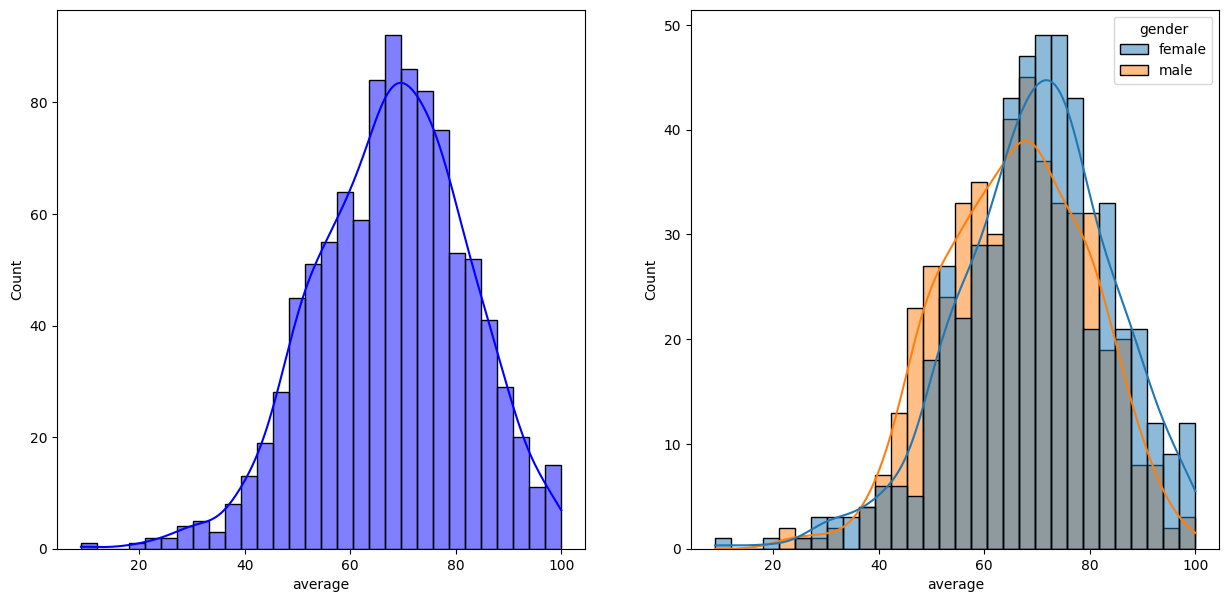

In [12]:
# exploring more visualizations
fig,axis=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121) # first plot
sns.histplot(data=df,x='average',bins=30,kde=True,color='blue')
plt.subplot(122) # second plot
sns.histplot(data= df , x = 'average', bins = 30 , kde = True , hue = 'gender')

In [ ]:
# insight : female students tend to perform well then males


<Axes: xlabel='average', ylabel='Count'>

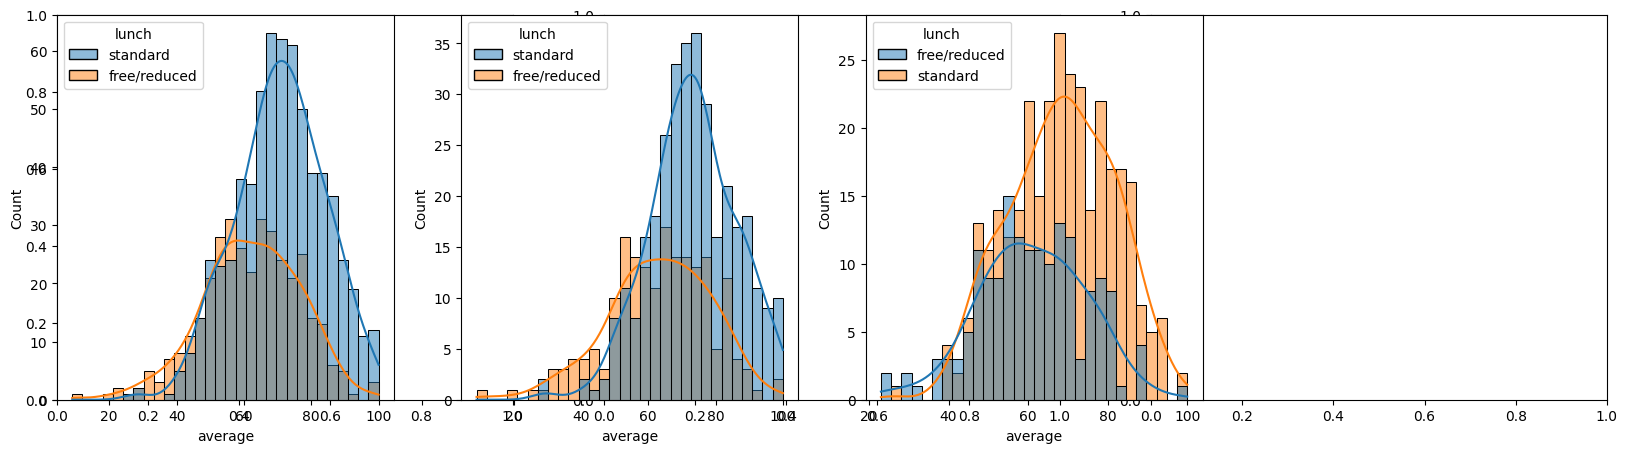

In [18]:
plt.subplots(1,3,figsize=(20,5))
plt.subplot(141)
sns.histplot(data=df,x='average',bins=30,kde=True,hue='lunch',color='blue')
plt.subplot(142)
sns.histplot(data= df[df['gender']=='female'] , x = 'average' , bins = 30 , kde = True , hue = 'lunch' )
plt.subplot(143)
sns.histplot(data= df[df['gender']=='male'] , x = 'average' , bins = 30 , kde = True , hue = 'lunch' )

insights :
standard lunch helps students perform well in exams 
standard lunch helps perform well in exam be it a male & female

<Axes: xlabel='average', ylabel='Count'>

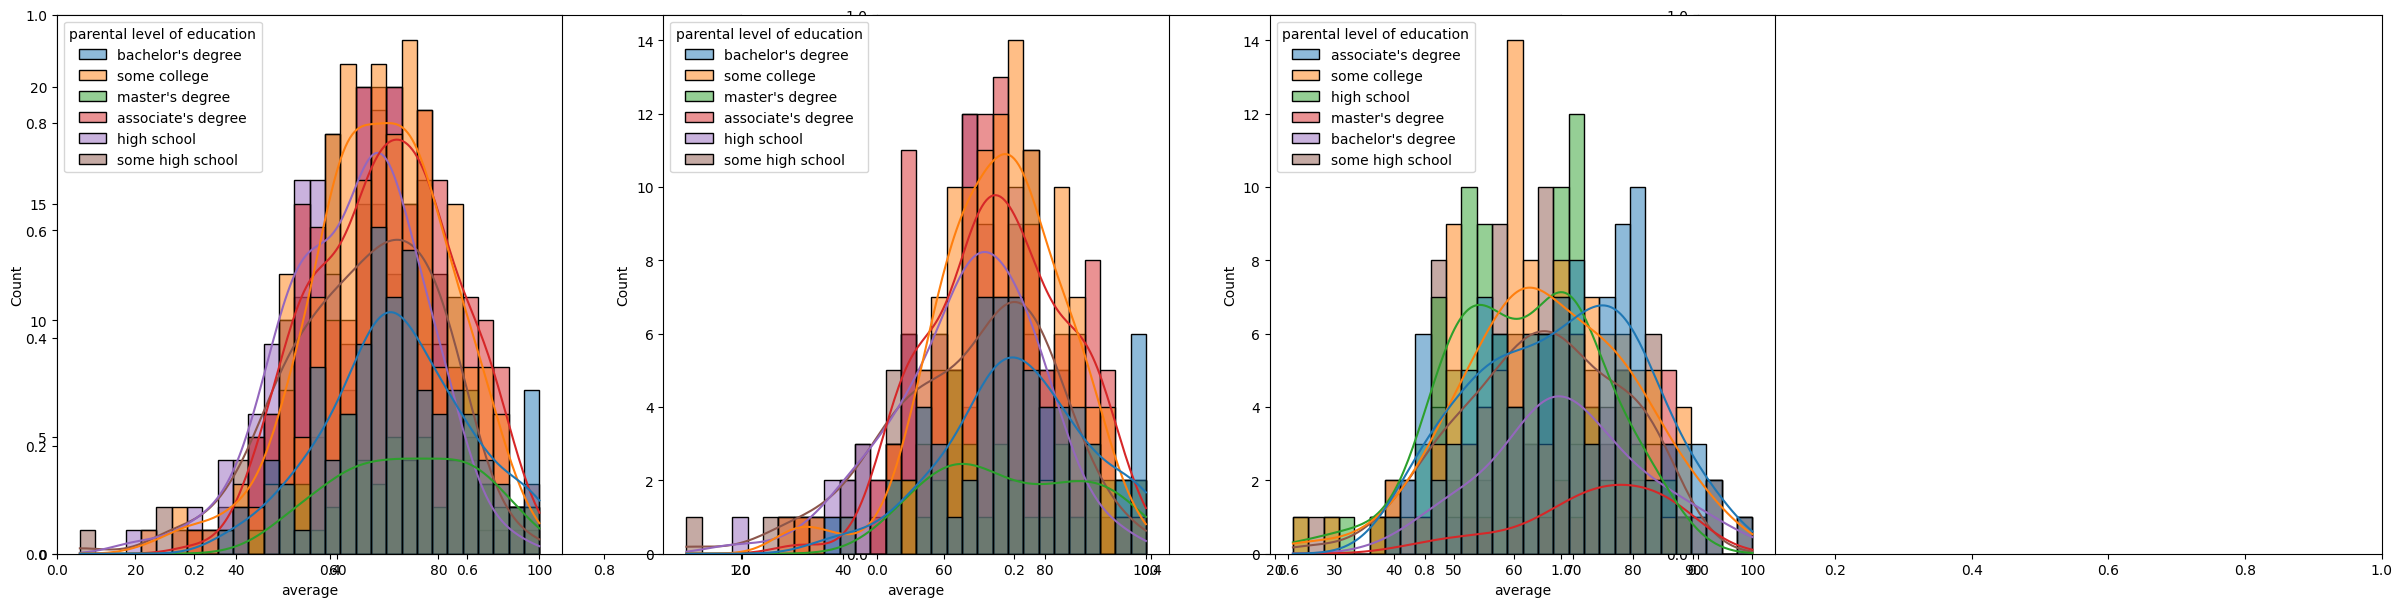

In [23]:
plt.subplots(1,3,figsize=(30,7))

plt.subplot(141)
sns.histplot(data=df, x='average', bins=30, kde=True, hue='parental level of education', color='blue')

plt.subplot(142)
sns.histplot(data=df[df['gender']=='female'], x='average', bins=30, kde=True, hue='parental level of education')

plt.subplot(143)
sns.histplot(data=df[df['gender']=='male'], x='average', bins=30, kde=True, hue='parental level of education')

insights
in general parent's education don't help student perform well in exam
3rd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam 
2nd plot we can see there is no effect of parent's education on female student 

<Axes: xlabel='average', ylabel='Count'>

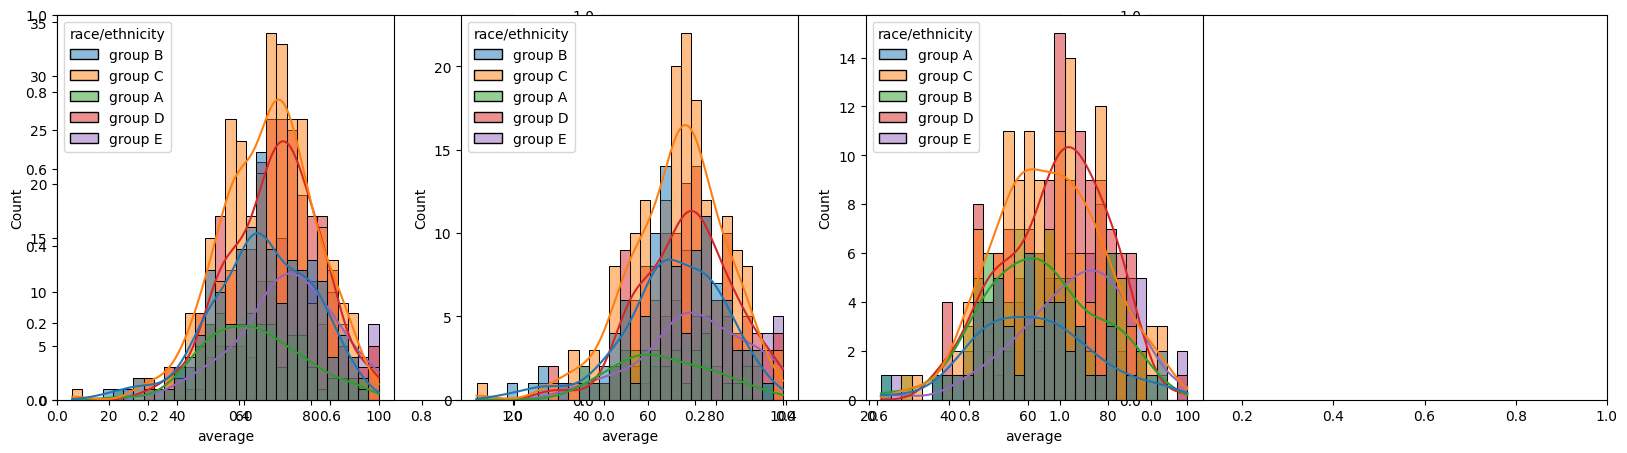

In [24]:
plt.subplots(1,3,figsize=(20,5))

plt.subplot(141)
sns.histplot(data=df, x='average', bins=30, kde=True, hue='race/ethnicity', color='blue')

plt.subplot(142)
sns.histplot(data=df[df['gender']=='female'], x='average', bins=30, kde=True, hue='race/ethnicity')

plt.subplot(143)
sns.histplot(data=df[df['gender']=='male'], x='average', bins=30, kde=True, hue='race/ethnicity')

student of group A amd B tends to perform poorly in exam 
Student of group A and B tends to perform poorly in exam irrespective of whether they are male or female

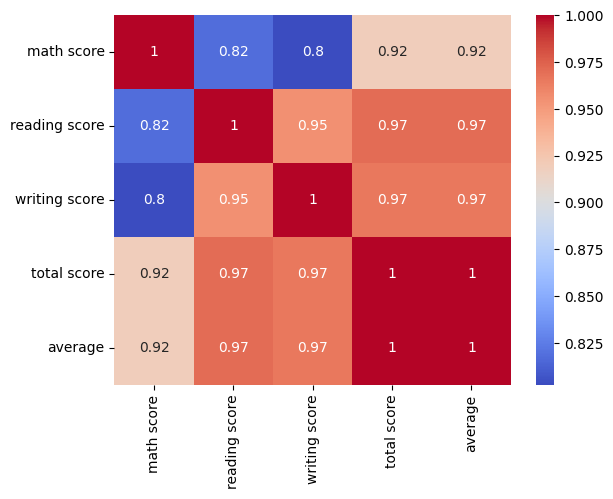

In [27]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation
corr_matrix = numeric_df.corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()